# Analyzing the Toxicity of Topics Over Time

In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import math

Importing a dataframe with information about videos, their topics, and their occurrences in messages. (Sample)

In [2]:
df_final = pd.read_csv("data/sample_yt_te_with_tox_top.csv")
display(df_final)

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,occurrences,toxicity,severe_toxicity,...,insult,identity_attack,topic,interest,perspective_insult,perspective_severe_toxicity,perspective_obscene,perspective_toxicity,perspective_identity_attack,perspective_threat
0,QKXr7N9c6Yo,roman islamic antichrist sonia azam explore bi...,Armageddon News,2021-10-11T16:36:04Z,2249.0,107.0,75.0,"[{'id': 28786, 'folder': 'channel_2165208912',...",0.003288,0.000109,...,0.000228,0.000284,0,1,0.378466,0.169603,0.003076,0.453968,0.460282,0.119229
1,qRFdVxvlXRY,kamala interview prove weak hope prove point w...,Real America's Voice,2024-10-08T14:57:04Z,498.0,89.0,10.0,"[{'id': 33565, 'folder': 'channel_1937328148',...",0.000926,0.000104,...,0.000195,0.000136,2,1,0.039152,0.003357,0.001997,0.104362,0.014953,0.009774
2,Y8KzbOkN_TM,money ttaakaa syllabus baire epbong welcome ep...,Your Bong Guy,2024-11-07T12:23:25Z,1198216.0,103644.0,5457.0,"[{'id': 3555926, 'folder': 'channel_1279841660...",0.005160,0.000092,...,0.000365,0.000166,-1,0,0.016177,0.002613,0.009595,0.030978,0.006845,0.008078
3,B5yS8olxa80,save israel jeremy gimpel live update frontlin...,thelandofisrael,2023-11-28T16:48:23Z,11835.0,1668.0,212.0,"[{'id': 37539, 'folder': 'channel_1592308283',...",0.002251,0.000098,...,0.000196,0.000200,4,1,0.024124,0.008583,0.007347,0.130411,0.102216,0.038221
4,JnvOJN5yF8s,kingdom planet official trailer cinemas yang b...,20th Century Studios Indonesia,2024-02-12T01:24:59Z,211122.0,1928.0,374.0,"[{'id': 422797, 'folder': 'channel_1905119305'...",0.001937,0.000101,...,0.000227,0.000176,-1,0,0.016861,0.003147,0.028147,0.067380,0.010951,0.019055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67352,-yqaSl75CWg,donald trump black conservative federation hon...,MAGNO NEWS,2024-02-24T03:36:18Z,132923.0,4173.0,694.0,"[{'id': 37202, 'folder': 'channel_1511714855',...",0.010595,0.000125,...,0.000510,0.000335,2,1,0.085581,0.013608,0.002221,0.205721,0.165871,0.022854
67353,B-9TmfJKIDw,revenge vseasy bgmi revange vvsvclutch vsclutc...,𝐒∆𝐈𝐘𝐀𝐍 • 127K views • 6 hours ago,2024-01-09T21:03:28Z,76.0,6.0,0.0,"[{'id': 202730, 'folder': 'channel_1215588509'...",0.586373,0.004986,...,0.080524,0.014184,-1,0,0.025929,0.010834,0.011866,0.083208,0.008694,0.008738
67354,5UfW-xNR7QE,stop celebrate year bible israel gaza jesus pa...,Aries Entertainment Podcast,2024-02-16T14:44:17Z,946556.0,NaN,3684.0,"[{'id': 561053, 'folder': 'channel_1905119305'...",0.126986,0.000889,...,0.003185,0.019822,4,1,0.047350,0.016448,0.004756,0.241222,0.249708,0.031660
67355,LwAVckmcj9k,know gaza bible israel jesus palestine youtube...,Aries Entertainment Podcast,2024-03-02T13:50:44Z,4215776.0,NaN,5746.0,"[{'id': 132237, 'folder': 'channel_1457622198'...",0.119244,0.000962,...,0.003629,0.018202,4,1,0.029714,0.011978,0.002999,0.154903,0.133773,0.025271


Opening the dataframe for each of the occurrences

In [3]:
# Converte a string para lista de dicts
def parse_occurrences(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

df_final['occ_list'] = df_final['occurrences'].apply(parse_occurrences)

# Explode a lista — uma linha por ocorrência
df_exploded = df_final.explode('occ_list', ignore_index=True)

# Extrai a data de cada ocorrência
df_exploded['date'] = df_exploded['occ_list'].apply(lambda x: x.get('date') if isinstance(x, dict) and 'date' in x else None)

# Converte para datetime
df_exploded['date'] = pd.to_datetime(df_exploded['date'], errors='coerce')

print(len(df_exploded))

336312


Calculating the average biweekly toxicity per topical

In [5]:
topic_names = {
    0: "Espiritualidade Sincrética e Práticas de Cura",
    1: "Música, Produção e Cultura Pop",
    2: "Mídia Conservadora e Política Americana",
    3: "Criptomoedas, Airdrops e Finanças Digitais",
    4: "Conflito Israel–Palestina e Oriente Médio",
    5: "Taiwan, China e Relações Geopolíticas Asiáticas",
    6: "Guerra Rússia–Ucrânia & Diplomacia Global",
    7: "Trailers, Cinema e Cultura Audiovisual",
    8: "Saúde Integrativa, Dietas e Pseudociência Online",
    9: "Automobilismo, Carros e Cultura de Oficina",
    10: "Clima Extremo e Desastres Naturais",
    11: "Canais Multilíngues e Conteúdo Diverso de YouTube",
    12: "Ensino e Apologética Islâmica",
    13: "Direitos Autorais e 'Fair Use' em Conteúdo Digital",
    14: "Jogos Digitais e Cultura Gamer",
    15: "Covid-19, Vacinas e Saúde Pública",
    16: "Jardinagem, Sustentabilidade e Autossuficiência",
    17: "Receitas Culinárias e Gastronomia Caseira",
    18: "Política Britânica e Figuras Partidárias",
    19: "Animais e Conteúdo Afetivo sobre Natureza",
    20: "Notícias Europeias e Política da União Europeia",
    21: "Bushcraft, Marcenaria e Vida ao Ar Livre",
    22: "Irlanda, Política e Identidade Nacional",
    23: "Índia, Educação e Política Local",
    24: "Tráfico Humano, Abuso Infantil e Justiça Criminal",
    25: "Humor, Stand-up e Entretenimento Cômico",
    26: "Economia do Iraque e Teorias de Revalorização Cambial",
    27: "Podcast Timcast e Mídia Política Independente",
    28: "Conteúdo Político de Direita e Benny Johnson",
    29: "Artes Marciais, Boxe e Cultura de Luta",
    30: "Vídeos Curtos e Cultura de Conteúdo Viral",
    31: "Polícia, Fiscalização e Auditorias Cidadãs",
    32: "Forças Armadas, Veteranos e Narrativas Militares",
    33: "Política Canadense — Trudeau × Poilievre",
    34: "Ideologia de Gênero e Debate sobre Transgeneridade",
    35: "Anticomunismo, Ideologias e Crítica Cultural",
    36: "Mudanças Climáticas, Energia e Ceticismo Ambiental",
    37: "África, Lideranças Políticas e Memória Pós-Colonial",
    38: "Dinesh D’Souza e Conservadorismo Midiático Americano",
    39: "Política Australiana e Liderança de Anthony Albanese",
    40: "Animação e Cultura Pop Digital",
    41: "Jogos Olímpicos e Atletas de Taiwan",
    42: "Sismos, Vulcões e Atividade Solar",
    43: "Modding e Root de Smartphones Xiaomi e Poco",
    44: "Atividade Solar e Eventos Espaciais",
    45: "Elon Musk e Iniciativas Tecnológicas",
    46: "Treinamento e Seminários de Armas de Fogo",
    47: "Cultura e Eventos em Hong Kong e China",
    48: "Família Real e Notícias de Monarquia",
    49: "Idiomas, Expressão e Cultura Juvenil",
    50: "Armas de Fogo e Armamentos Táticos",
    51: "História da Alemanha Nazista e Adolf Hitler",
    52: "Incêndios, Explosões e Emergências",
    53: "Jimmy Dore / The Jimmy Dore Show",
    54: "Pesca e Atividades Recreativas",
    55: "Duran, Crypto e Conteúdo Musical",
    56: "Notícias Armênias e Política Local",
    57: "Redact News e Jornalismo Financeiro",
    58: "Mahyar Tousi e Merchandise Patriótico",
    59: "Sean 'Diddy' Combs e Questões Legais",
    60: "Alight Motion e Edição de Conteúdo Digital",
    -1: "Ruído / Sem Tópico"
}


In [6]:
most_toxic_topics = [2, 4, 5, 6, 10, 12, 13, 15, 18, 20, 22, 23, 24, 26, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 39, 42, 47, 51, 56, 59]
less_toxic_topics = [0, 1, 7, 8, 9, 14, 16, 17, 19, 25, 29, 40, 41, 44, 45, 46, 48, 50, 52, 53, 57]

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.lines import Line2D

def plot_toxicity_groups(df, topic_list, title_label, group_size=7):

    df_subset = df[df["topic"].isin(topic_list)].copy()
    df_subset["topic_name"] = df_subset["topic"].map(topic_names)

    unique_topics = sorted(df_subset["topic"].unique())
    num_groups = math.ceil(len(unique_topics) / group_size)

    sns.set(style="whitegrid")

    # paleta de 7 cores super distintas
    distinct7 = [
         "#0000FF",  
        "#DA0000",  
        "#00CC00",  
        "#FF66CC", 
        "#522222", 
        "#FF9900",  
        "#962EAA"
    ]

    for i in range(num_groups):

        group_topics = unique_topics[i * group_size : (i + 1) * group_size]
        group_df = df_subset[df_subset["topic"].isin(group_topics)].copy()

        plt.figure(figsize=(14, 6))

        # atribui uma das 7 cores distintas
        colors = {t: distinct7[j % 7] for j, t in enumerate(group_topics)}

        for t in group_topics:
            t_df = group_df[group_df["topic"] == t]
            plt.plot(
                t_df["date"],
                t_df["perspective_toxicity"],
                marker="o",
                label=topic_names[t],
                color=colors[t]
            )

        plt.title(f"Evolução da Toxicidade ({title_label}) — Tópicos {group_topics[0]} a {group_topics[-1]}")
        plt.xlabel("Período (mês)")
        plt.ylabel("Toxicidade média")
        plt.ylim(0, 0.6)
        plt.xticks(rotation=45)

        # Legenda com quadradinhos
        handles = [
            Line2D([0], [0], marker="s", linestyle="",
                   color=colors[t], markersize=12, label=topic_names[t])
            for t in group_topics
        ]

        plt.legend(handles=handles, title="Tópico",
                   bbox_to_anchor=(1.05, 1), loc="upper left")

        plt.tight_layout()


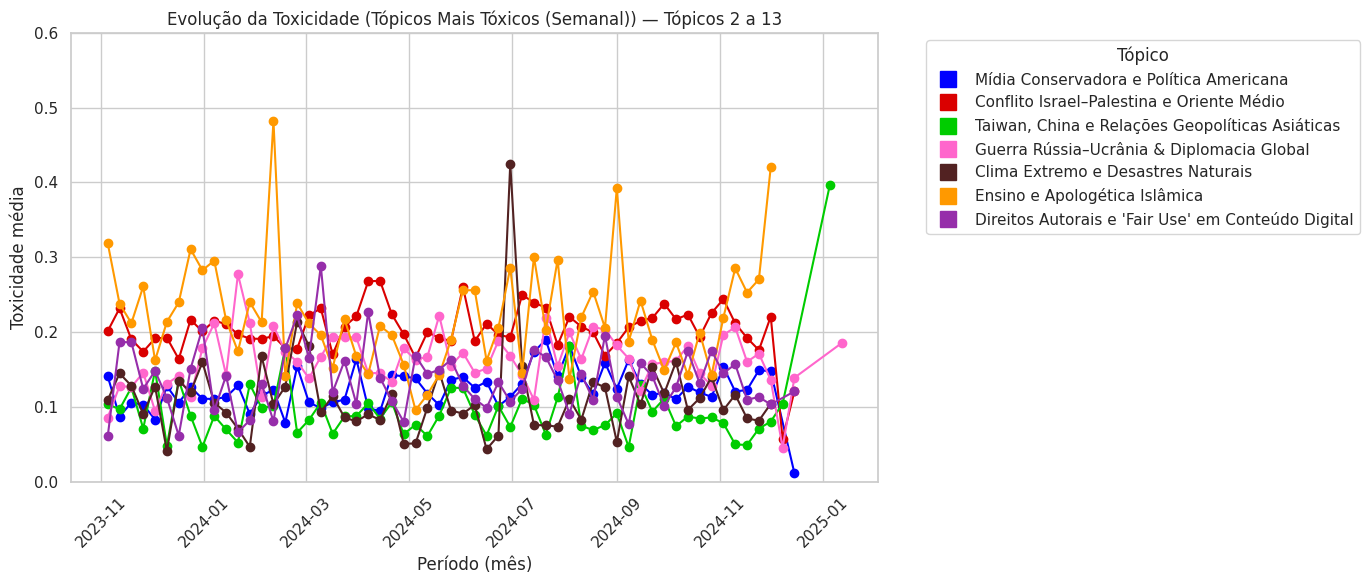

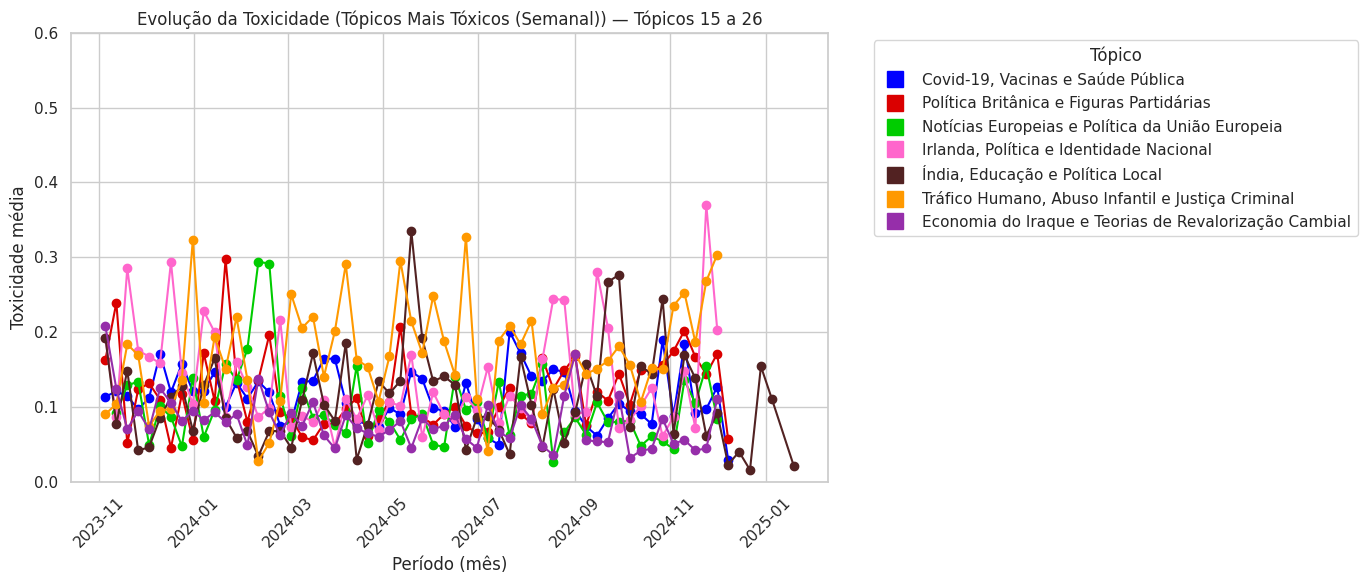

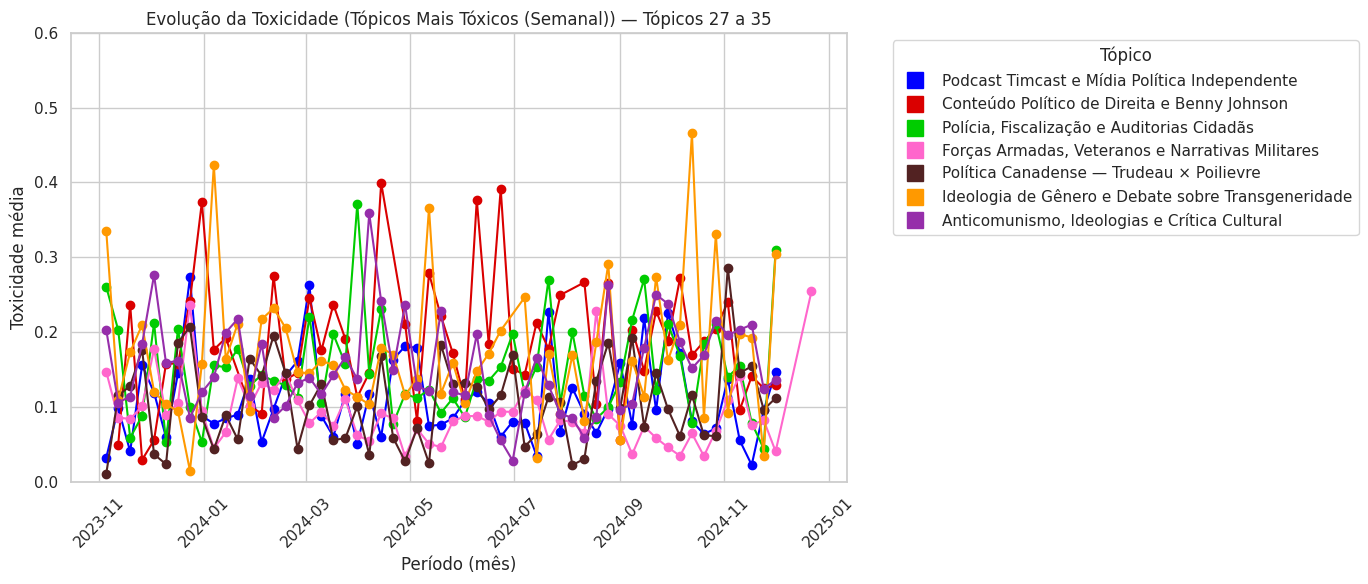

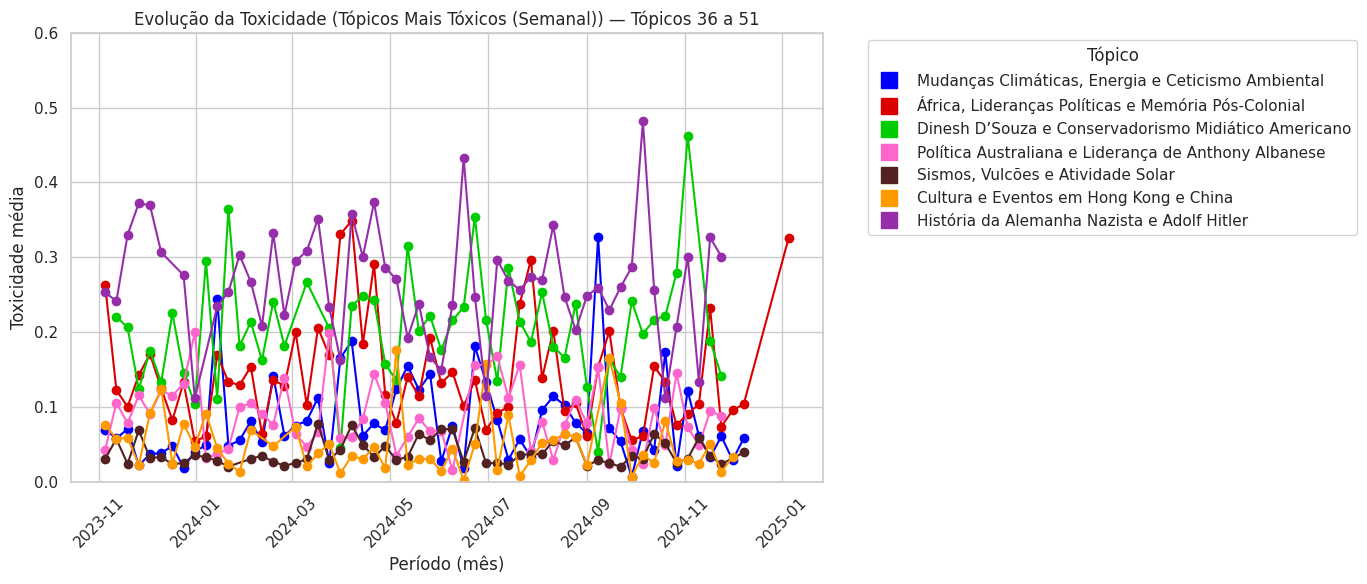

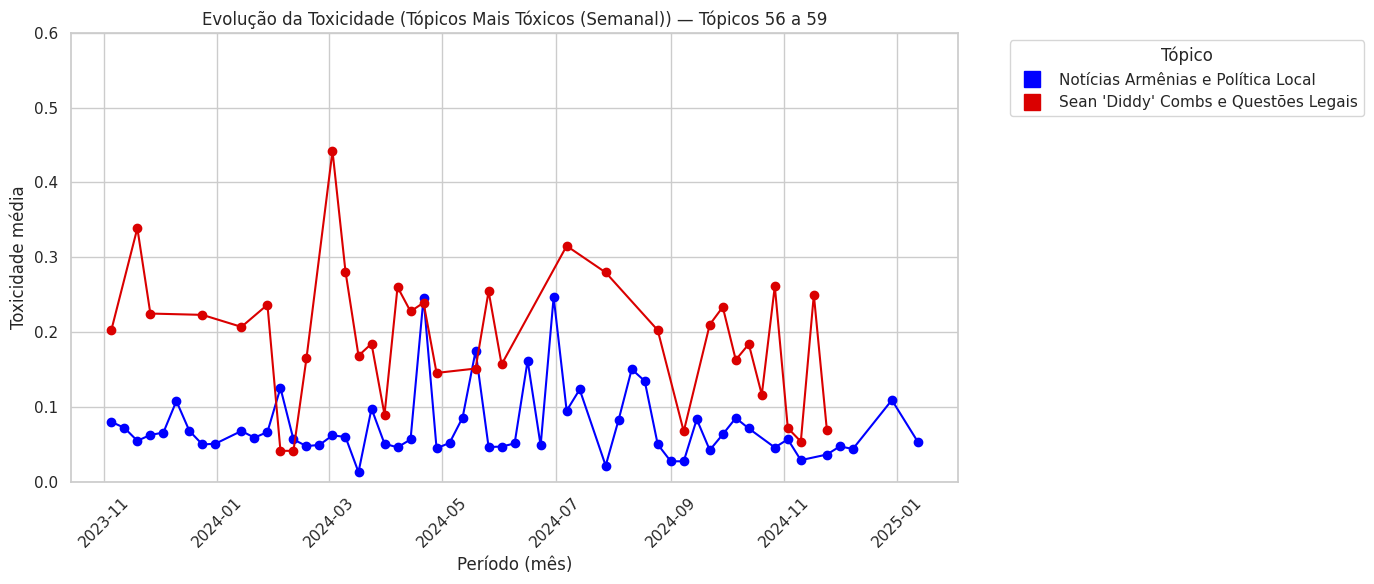

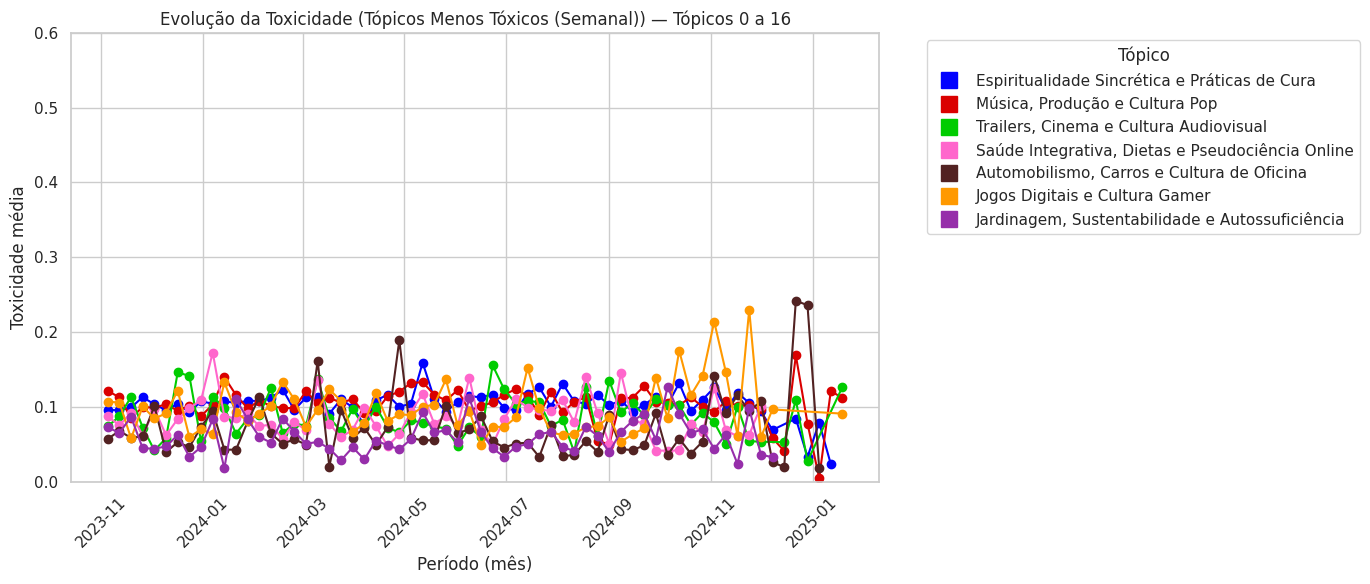

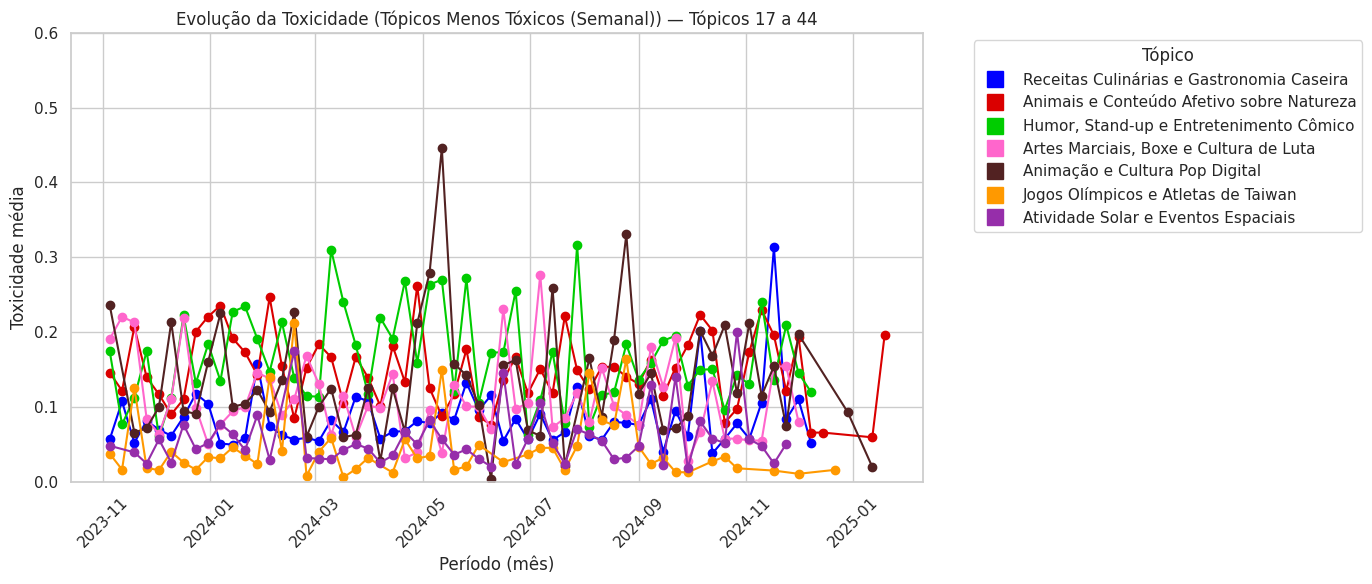

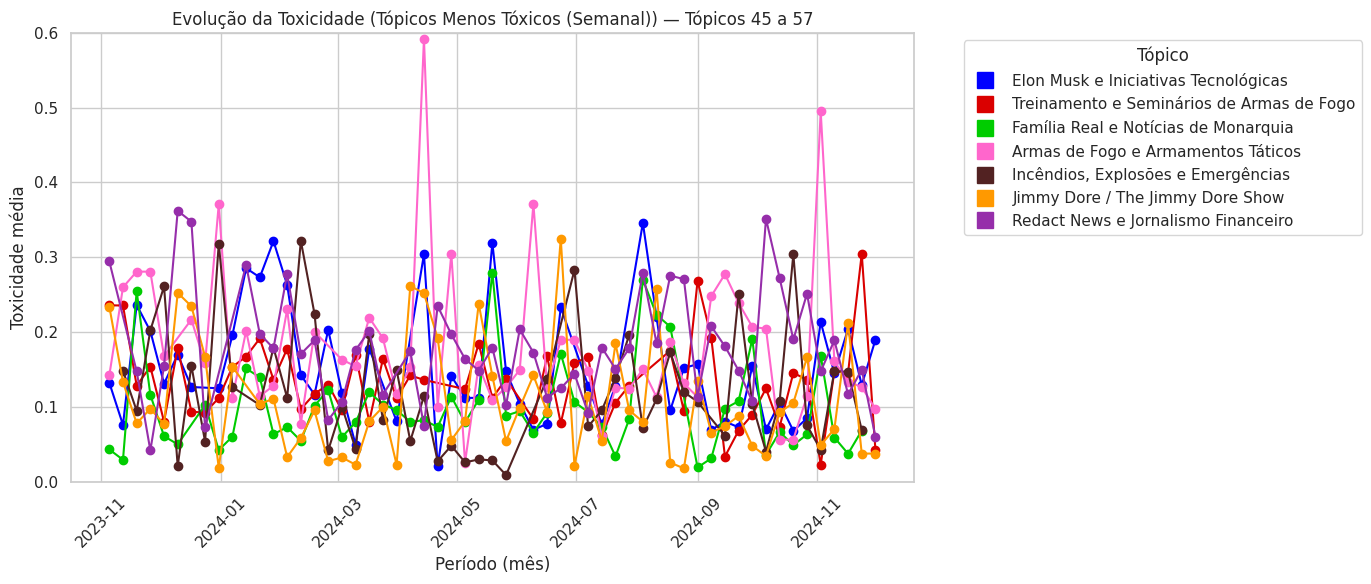

In [18]:
# Calcula a toxicidade média semanal por tópico
df_weekly_tox = (
    df_exploded
    .groupby([
        "topic",
        pd.Grouper(key="date", freq="W")  # frequência semanal
    ])
    [["perspective_toxicity"]]
    .mean()
    .reset_index()
)

plot_toxicity_groups(df_weekly_tox, most_toxic_topics, "Tópicos Mais Tóxicos (Semanal)")
plot_toxicity_groups(df_weekly_tox, less_toxic_topics, "Tópicos Menos Tóxicos (Semanal)")


In [21]:
# Calcula a toxicidade média mensal por tópico
df_monthly_tox = (
    df_exploded
    .groupby([
        "topic",
        pd.Grouper(key="date", freq="M")  # frequência mensal
    ])
    [["perspective_toxicity"]]
    .mean()
    .reset_index()
)

display(df_monthly_tox)

/tmp/ipykernel_1216540/1316468220.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key="date", freq="M")  # frequência mensal


,topic,date,perspective_toxicity
0,-1,2023-11-30,0.116180
1,-1,2023-12-31,0.115755
2,-1,2024-01-31,0.114671
3,-1,2024-02-29,0.128440
4,-1,2024-03-31,0.126894
...,...,...,...
852,60,2024-09-30,0.272080
853,60,2024-10-31,0.039880
854,60,2024-11-30,0.034964
855,60,2024-12-31,0.050540


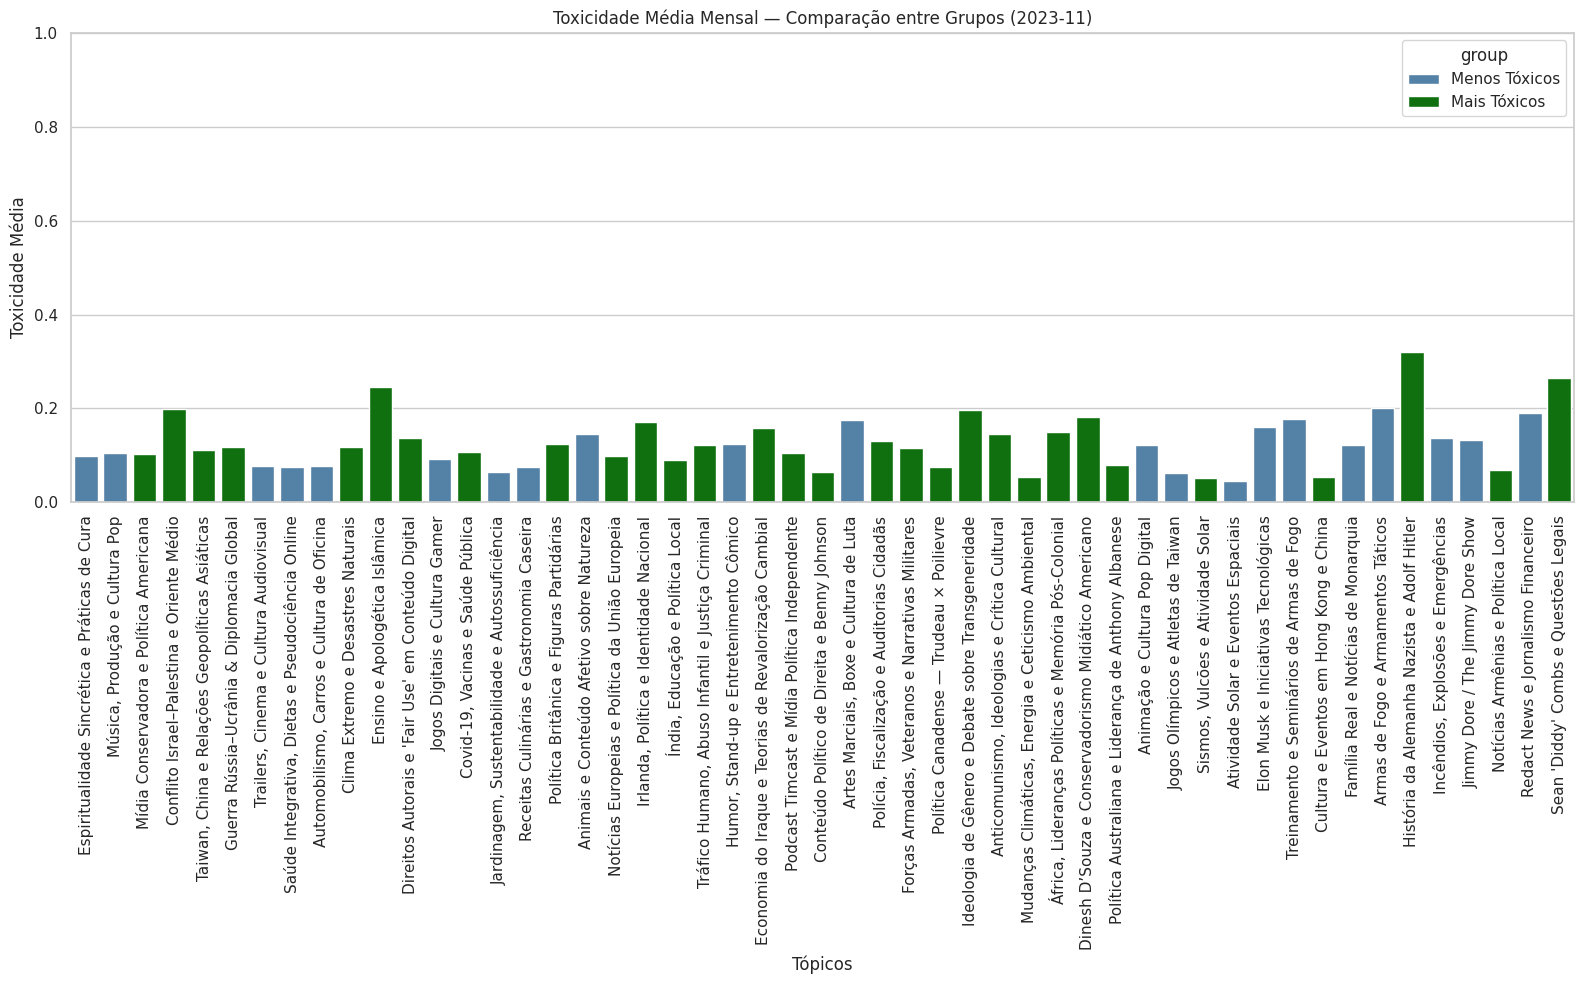

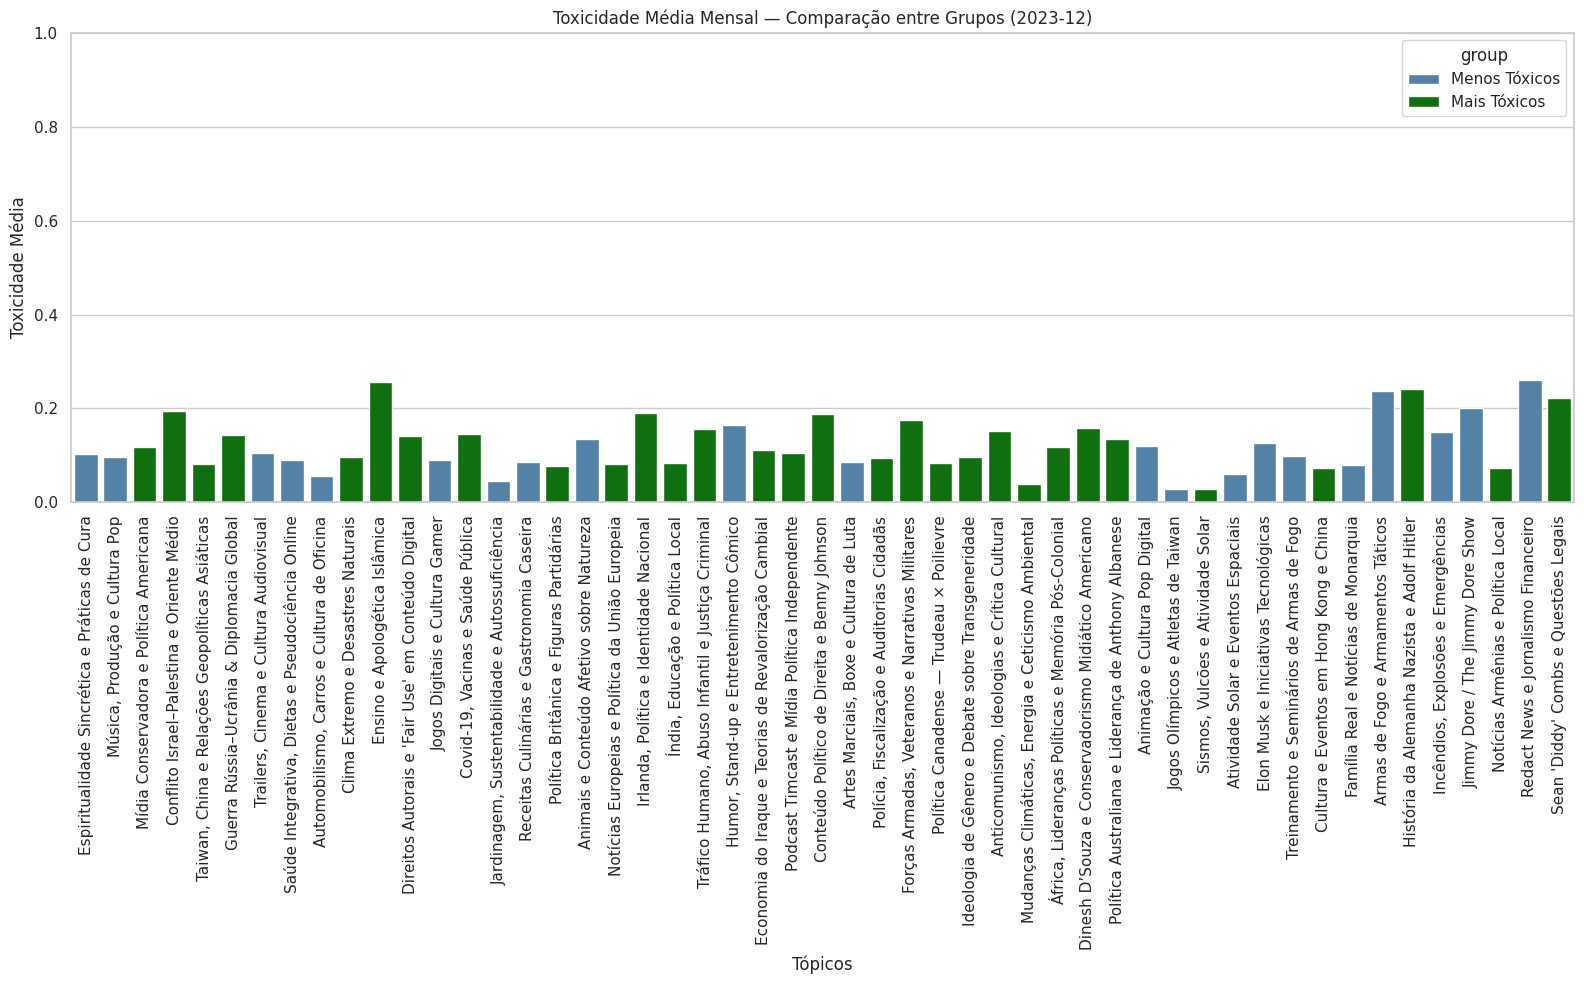

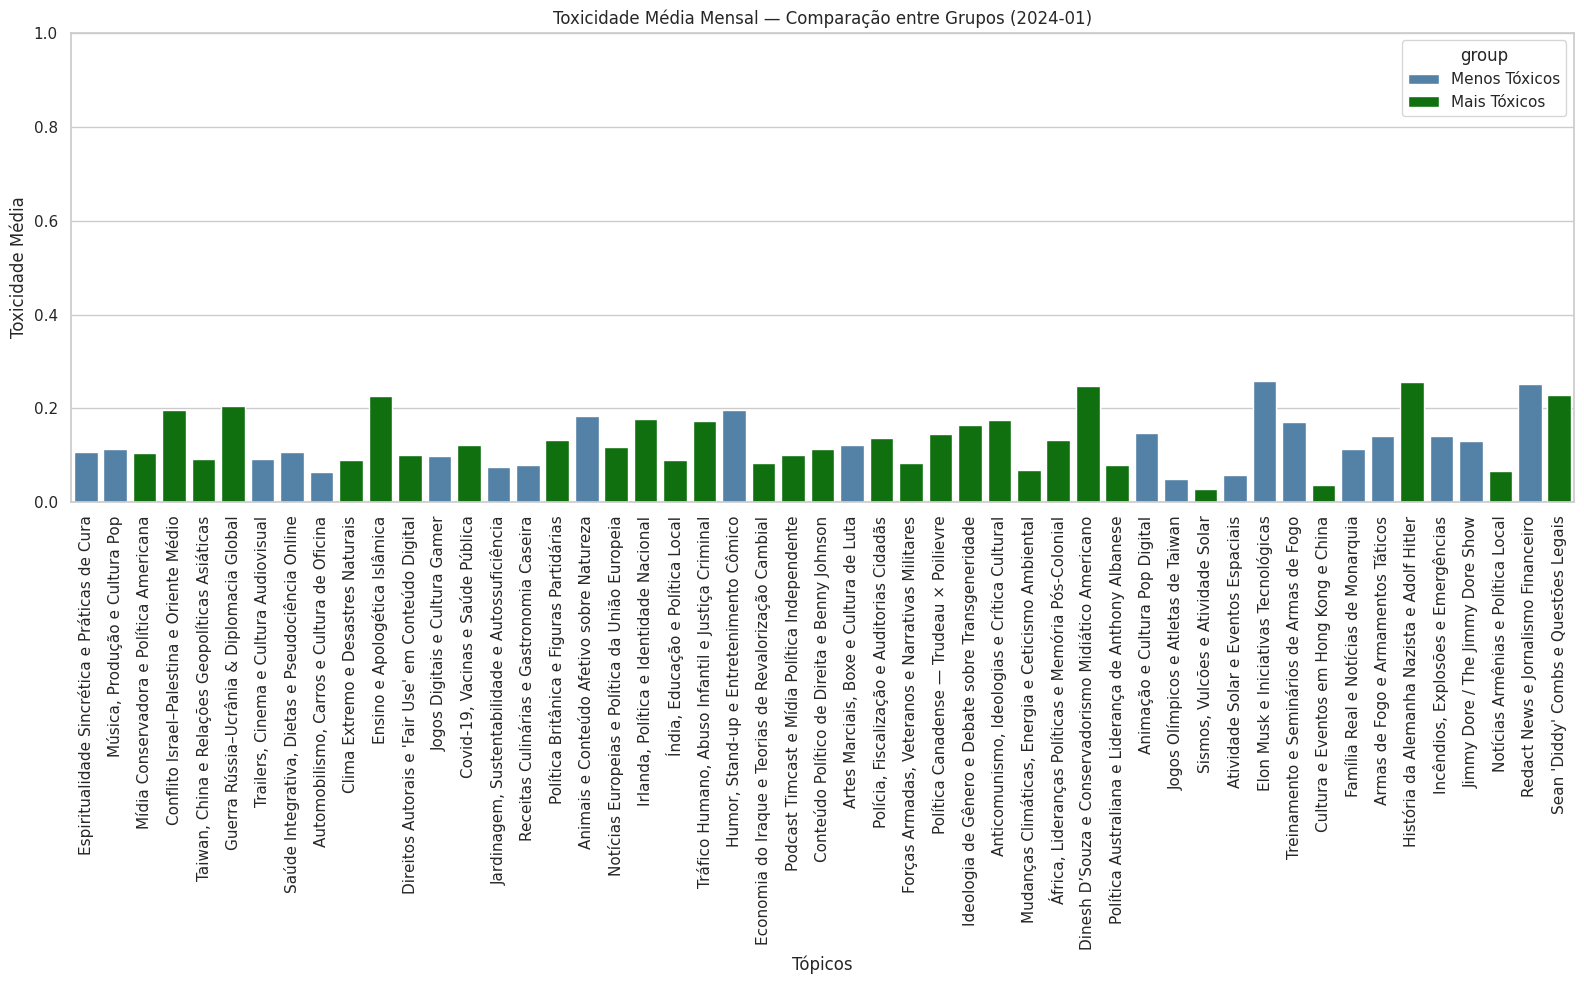

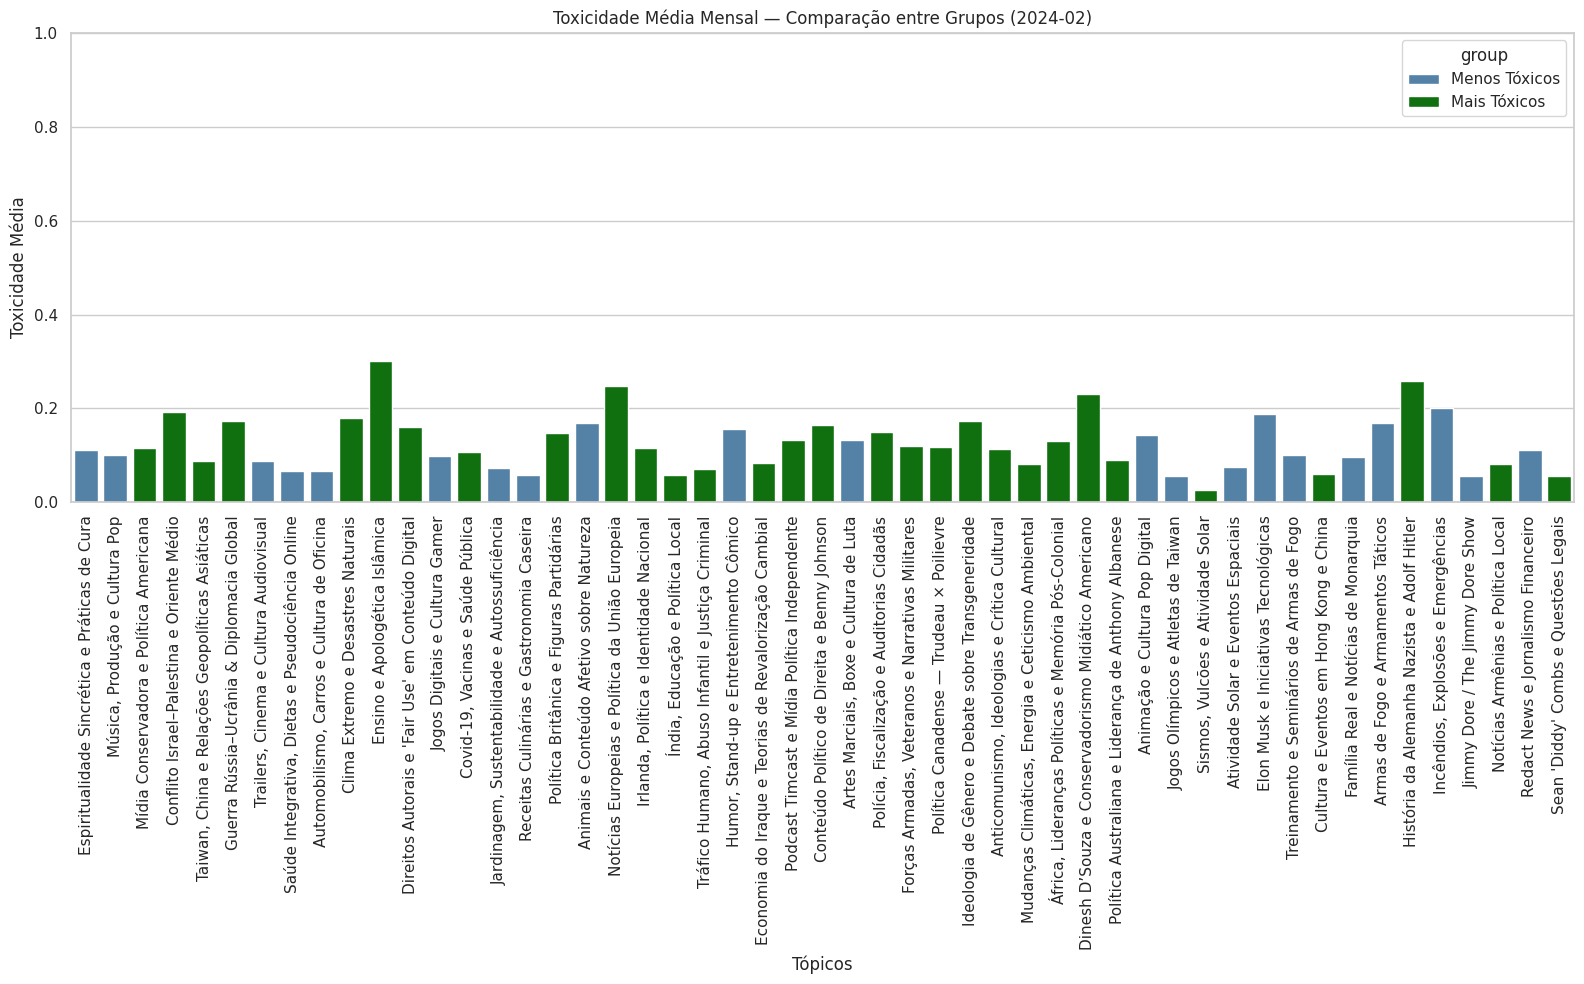

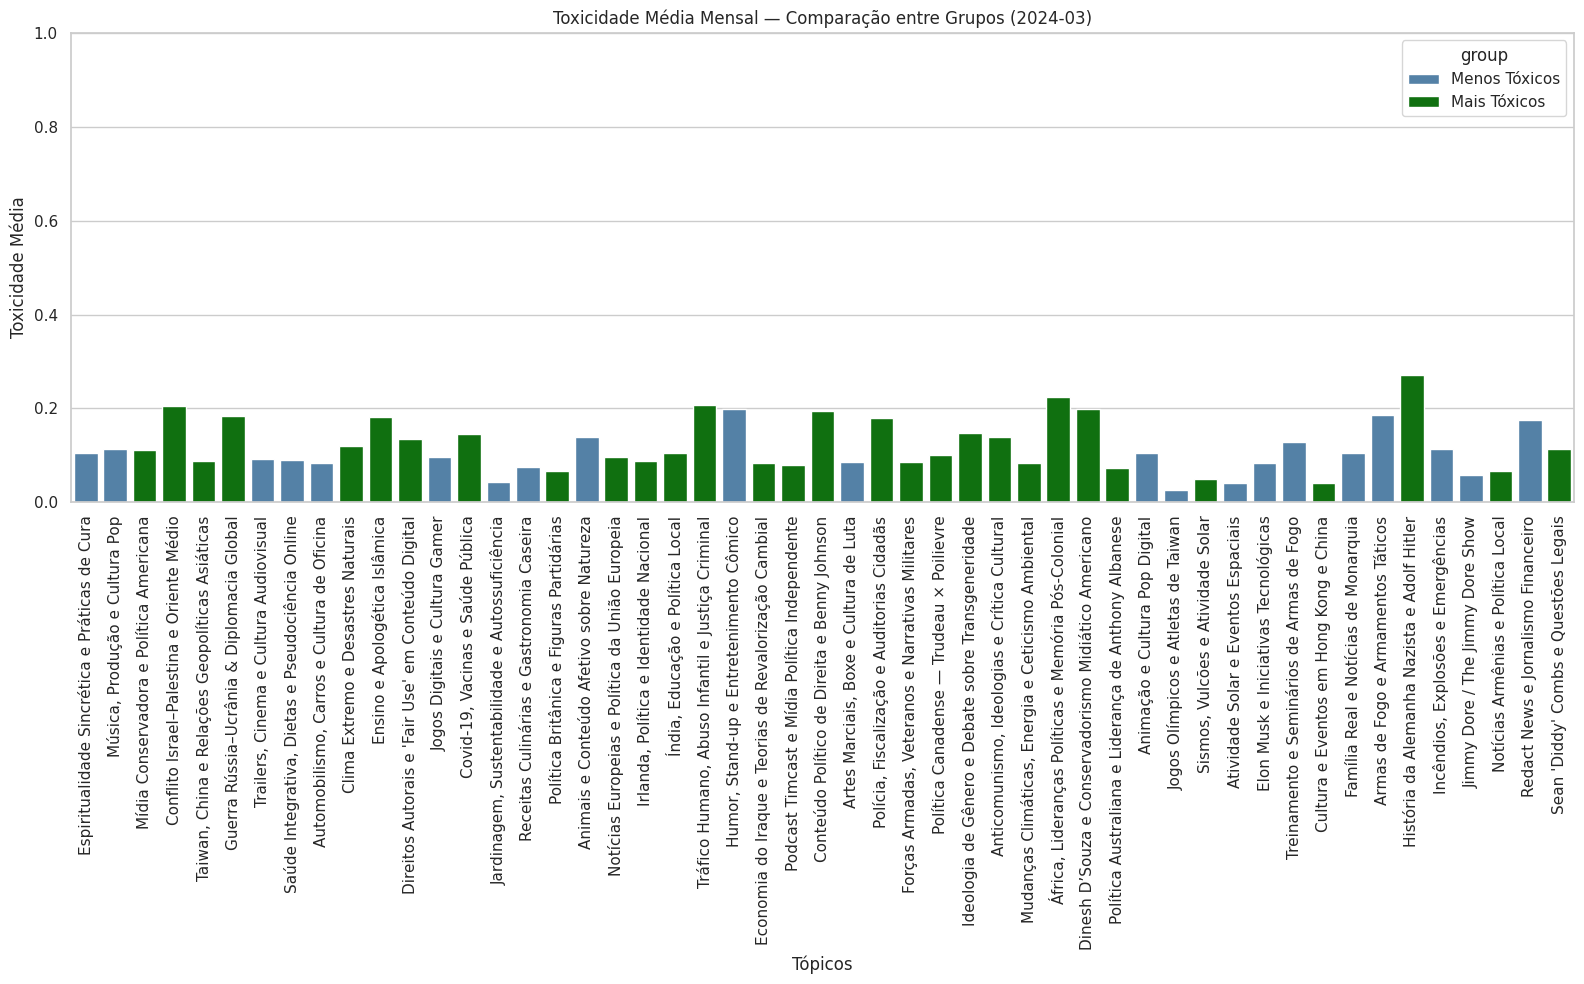

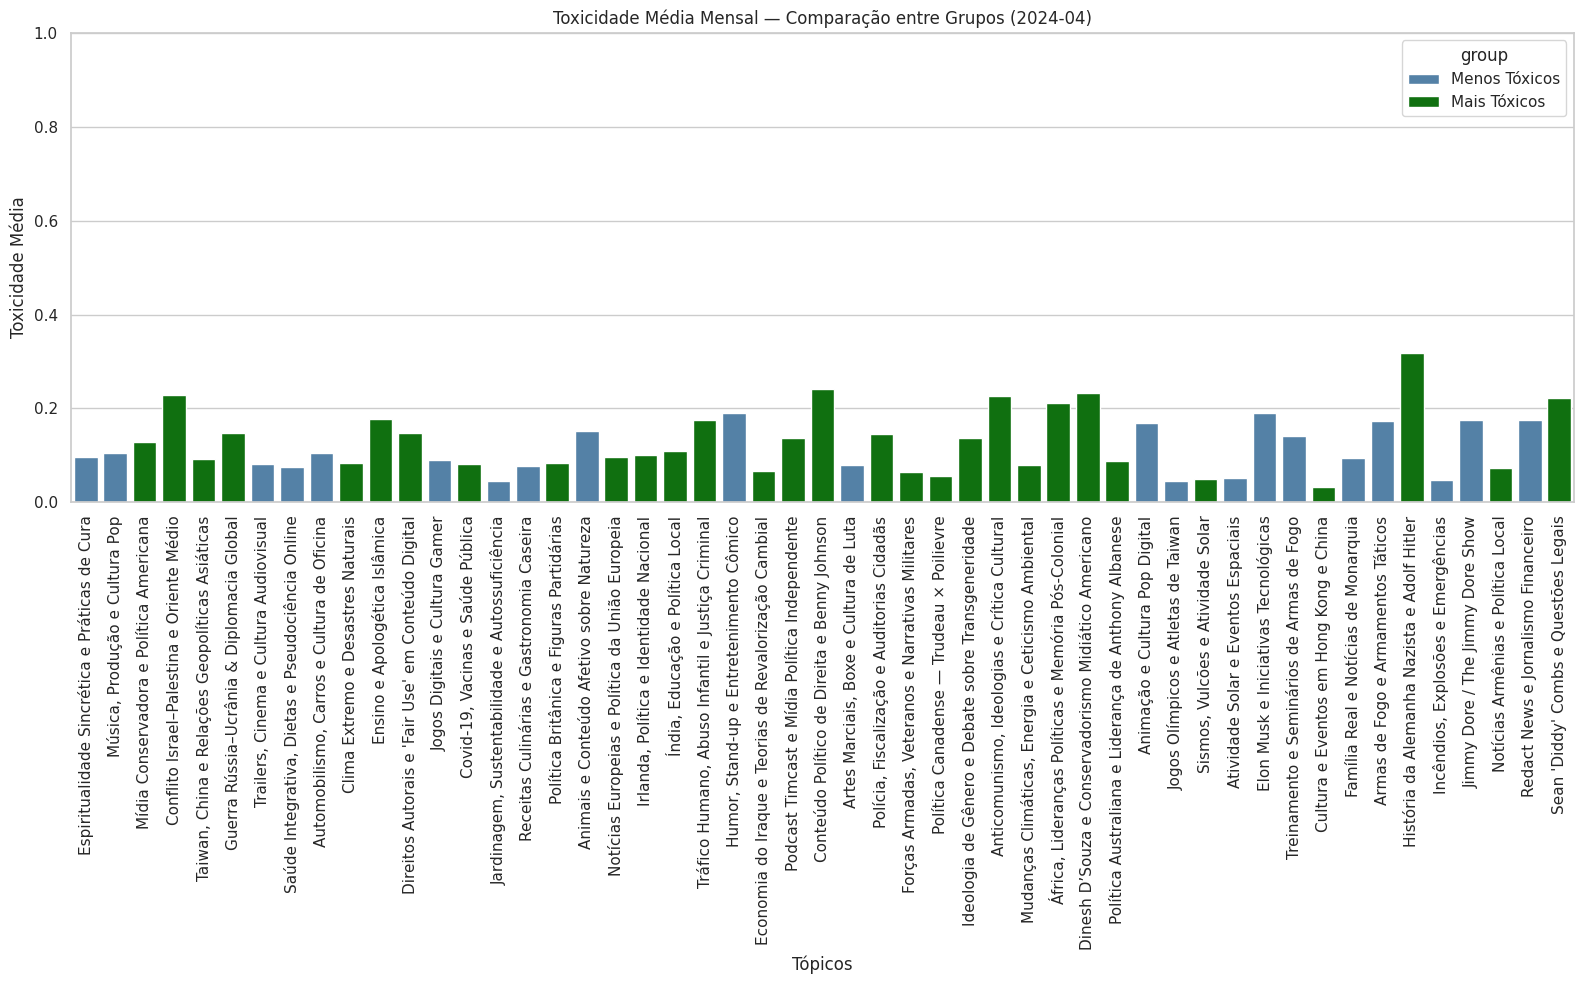

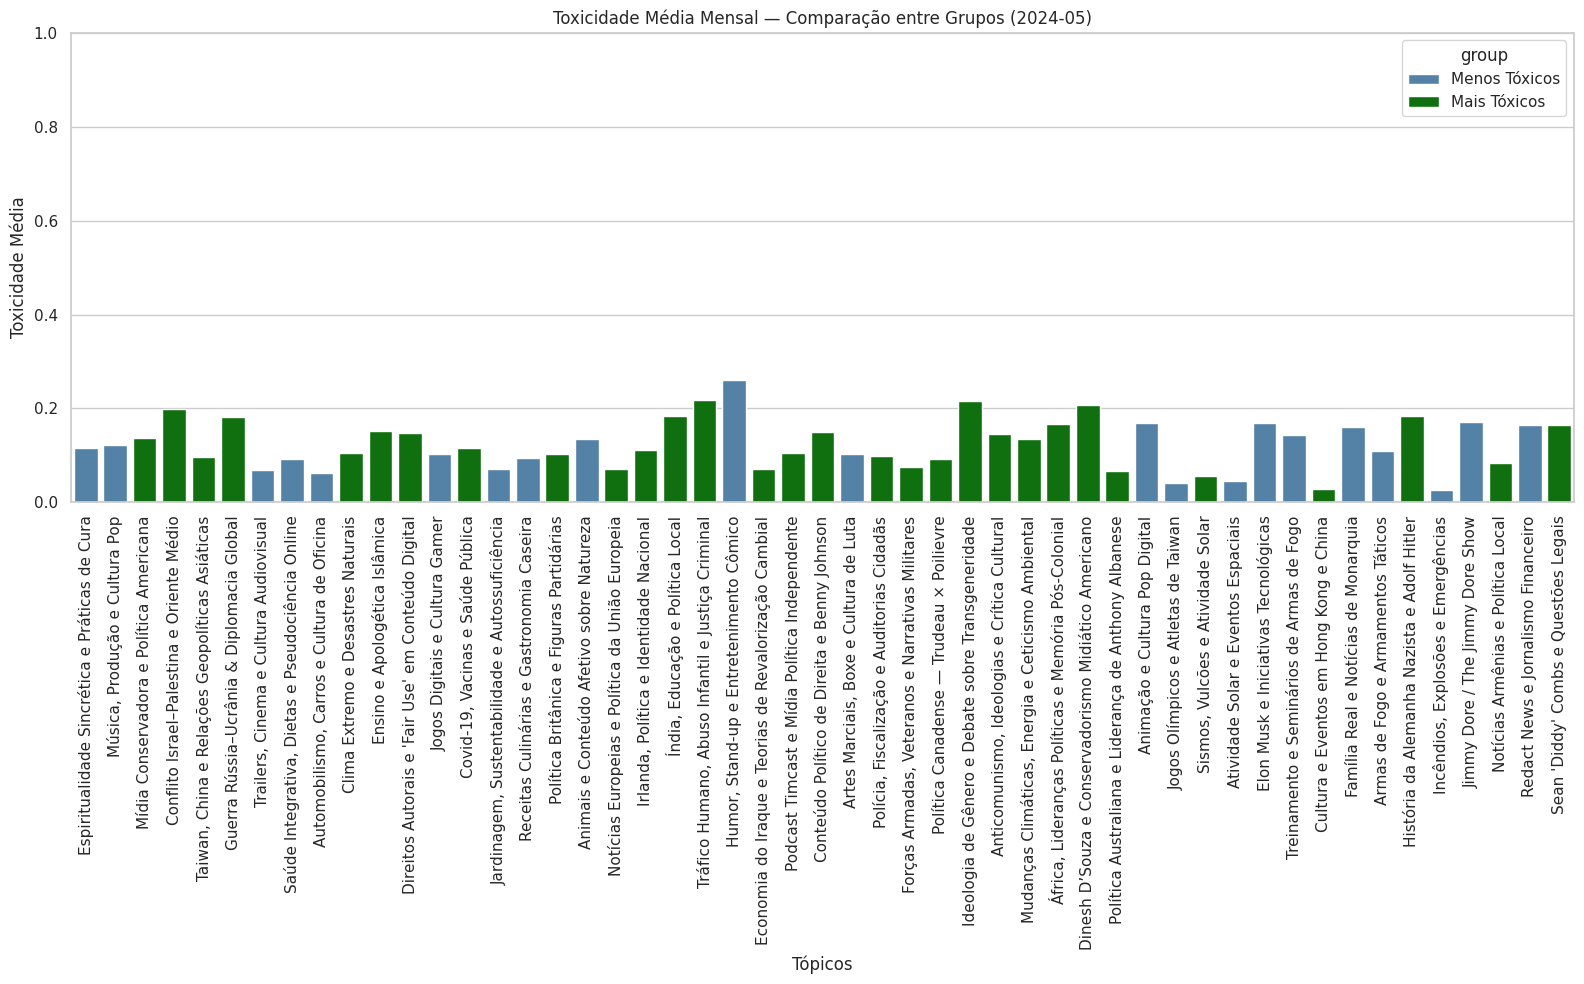

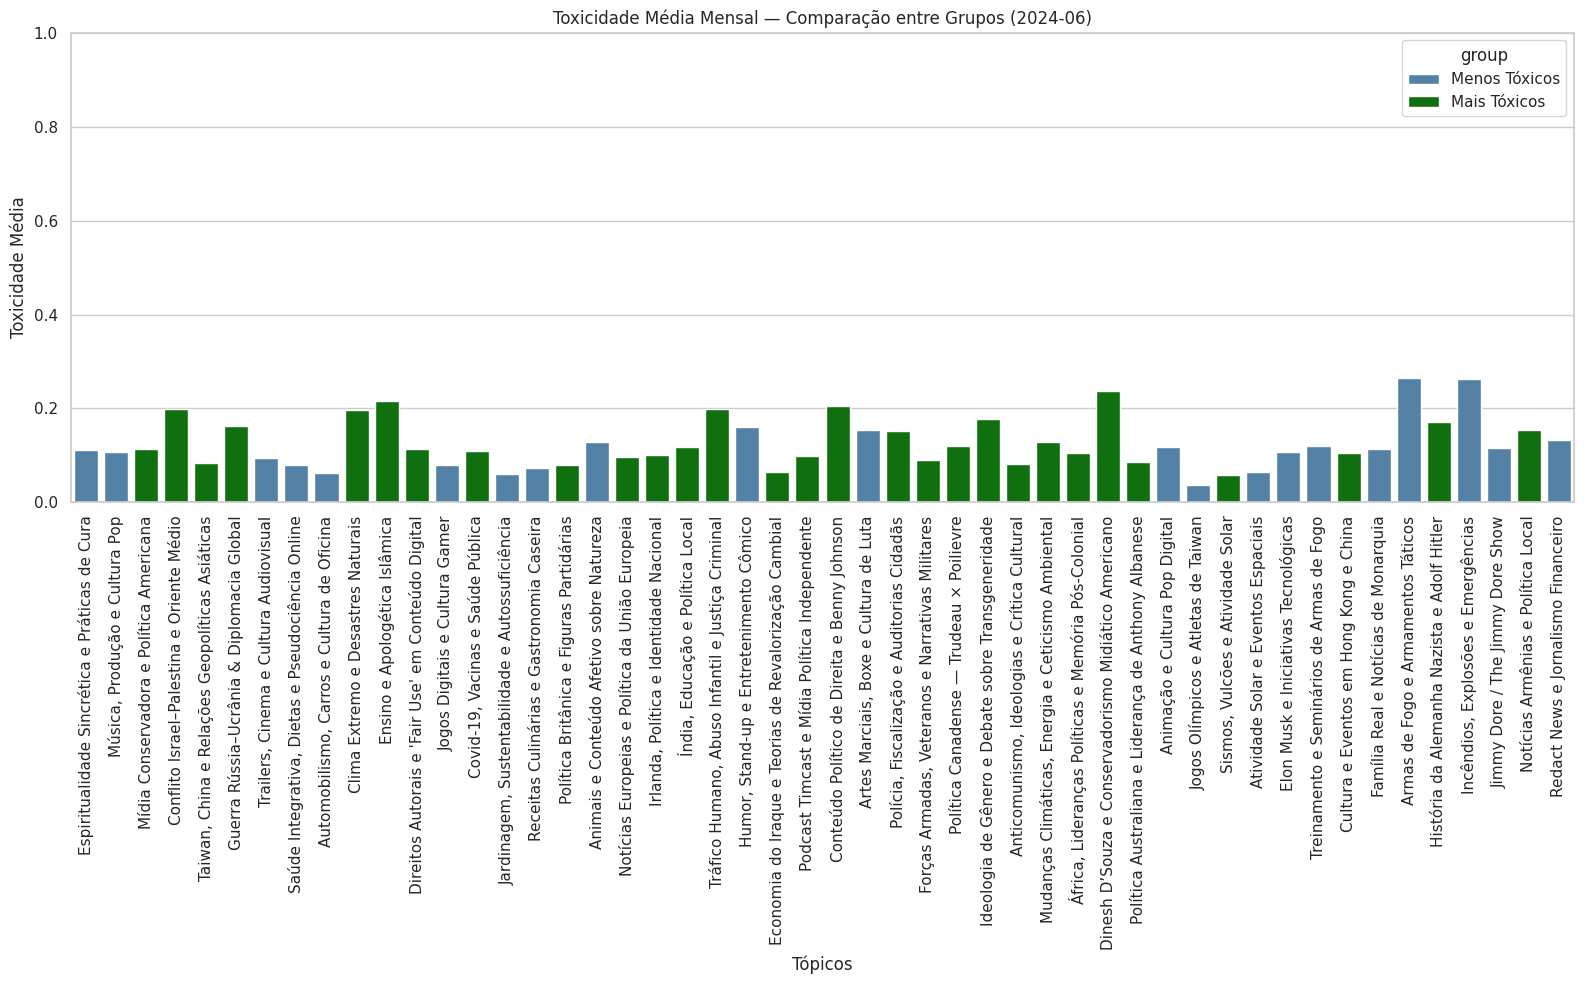

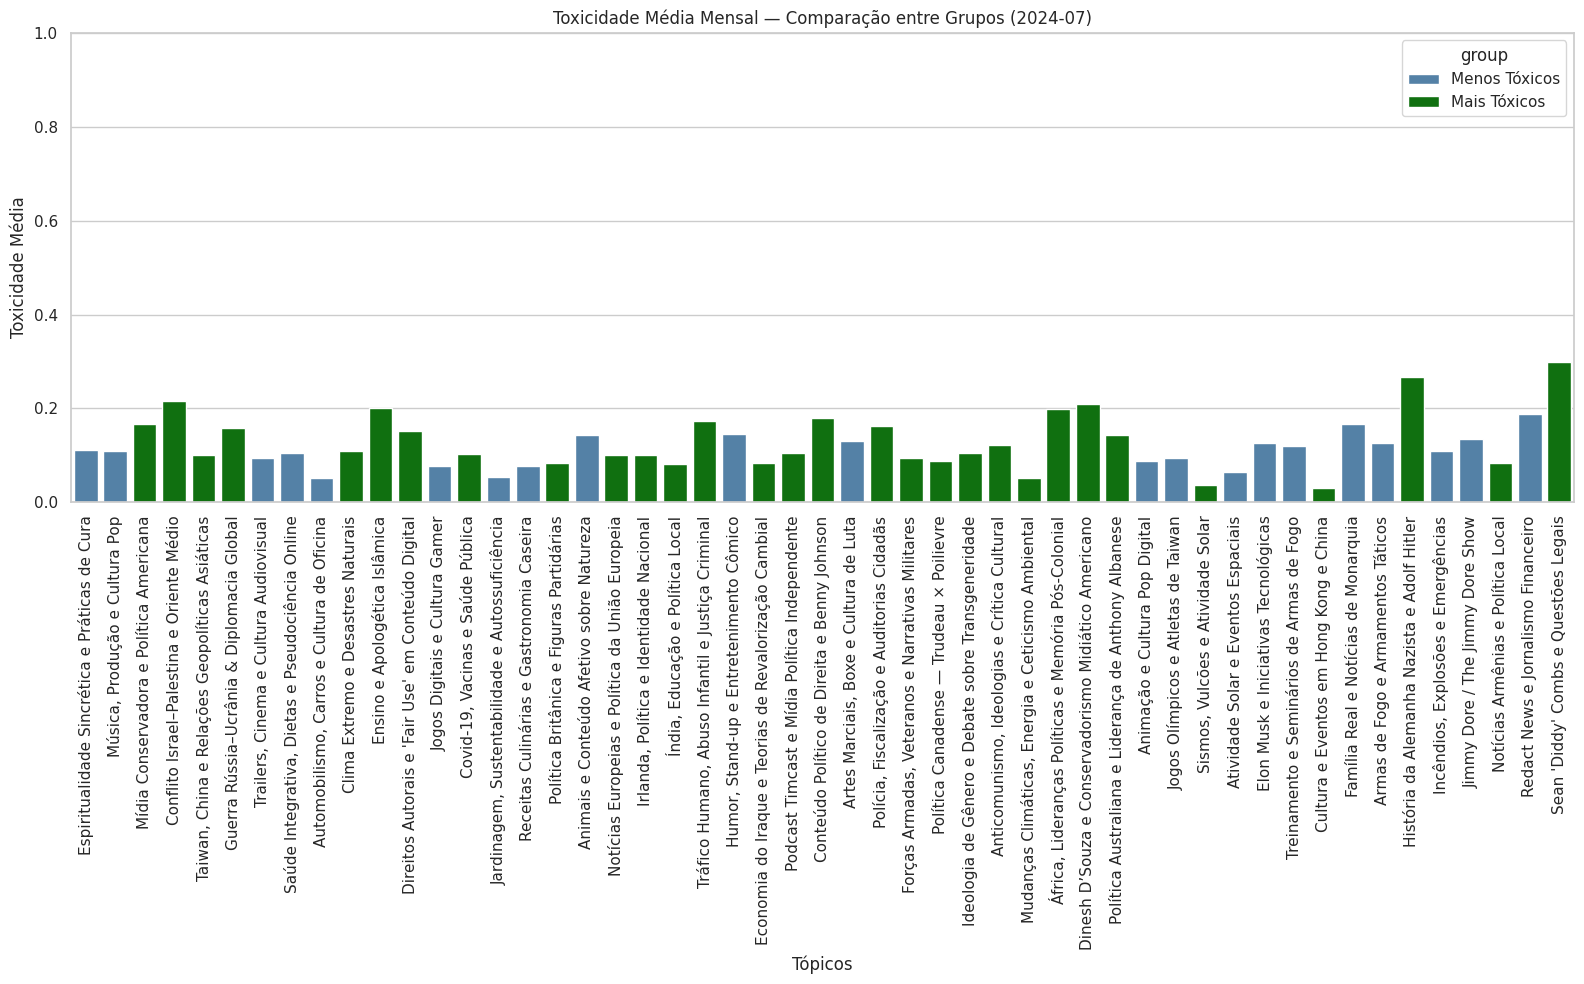

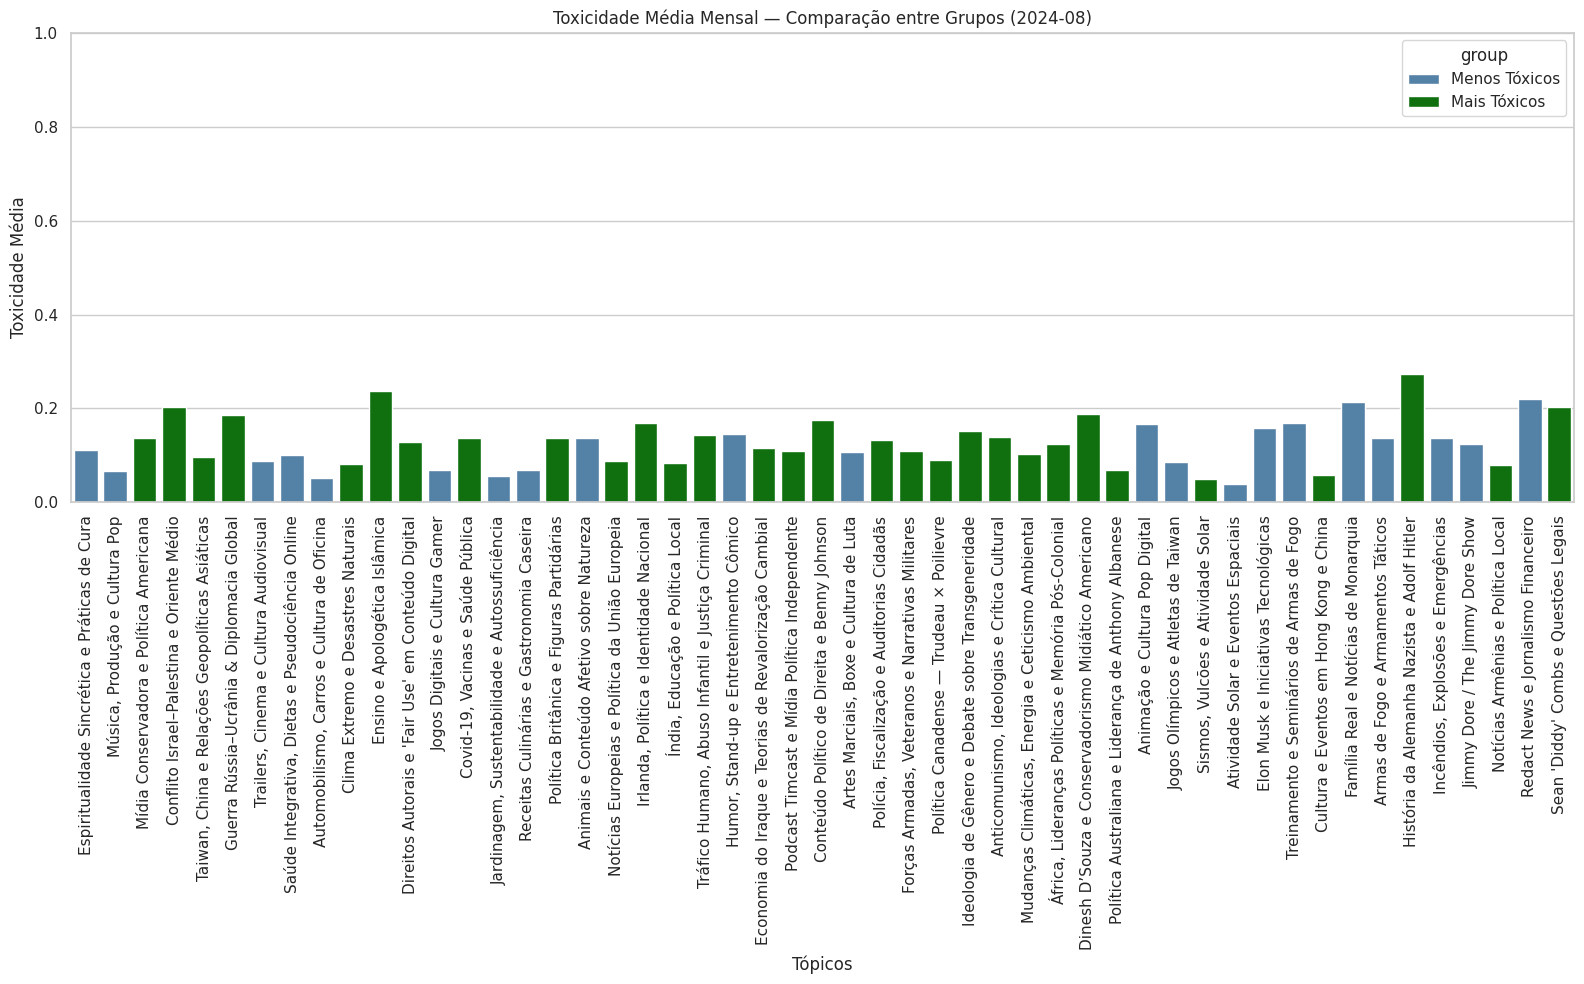

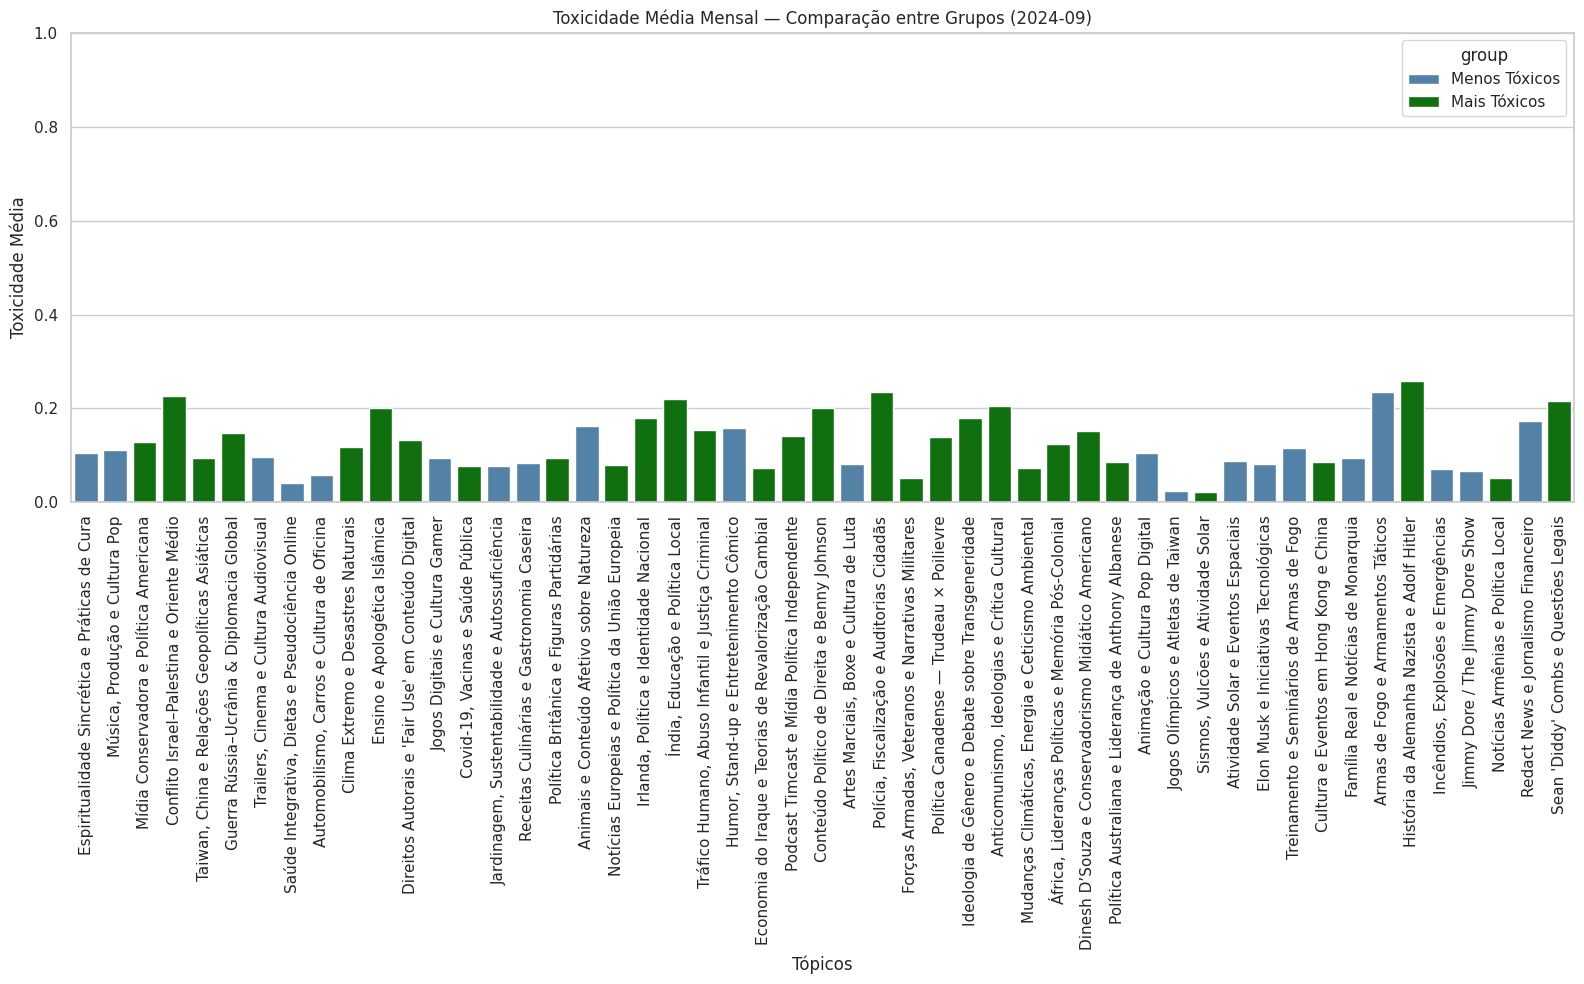

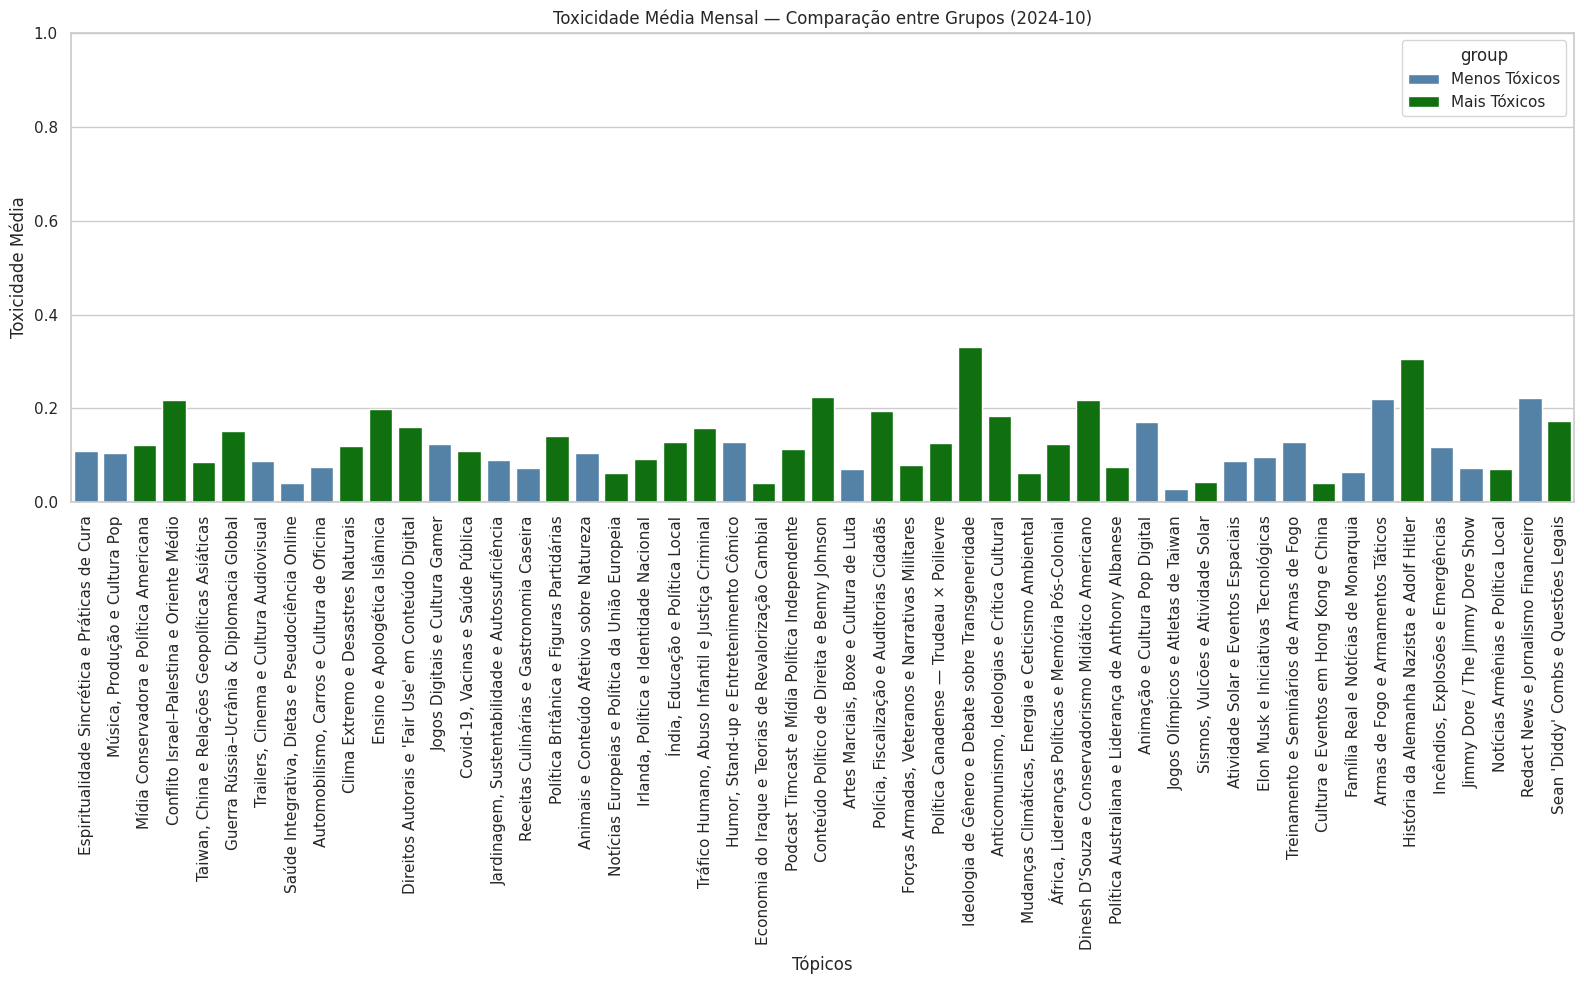

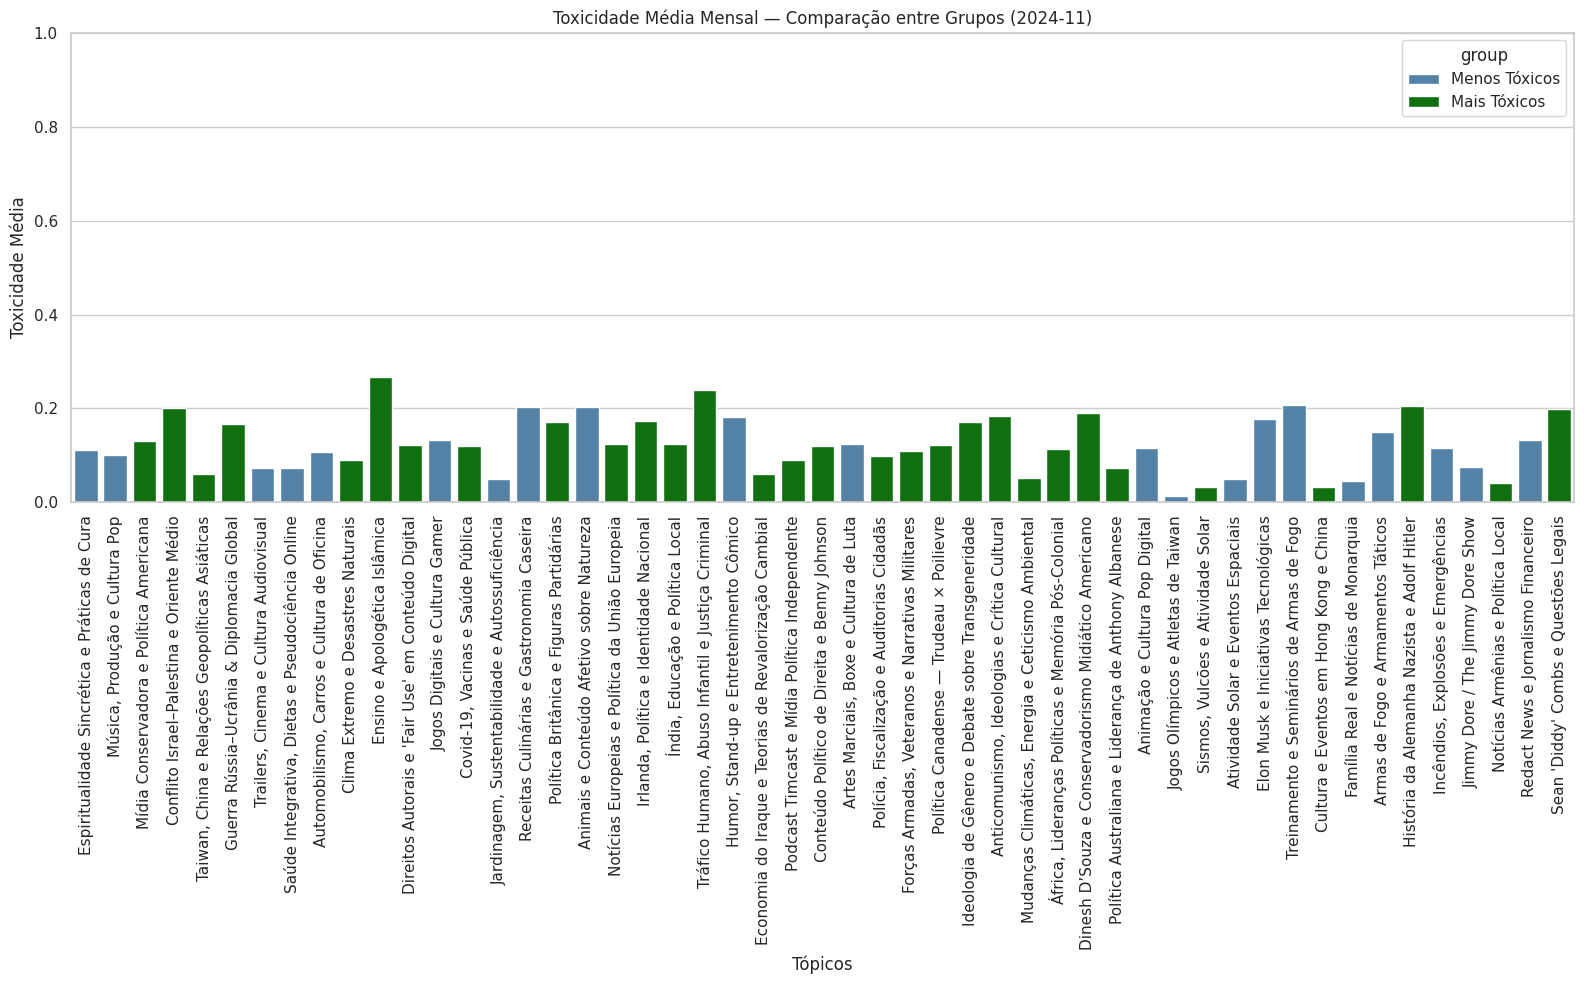

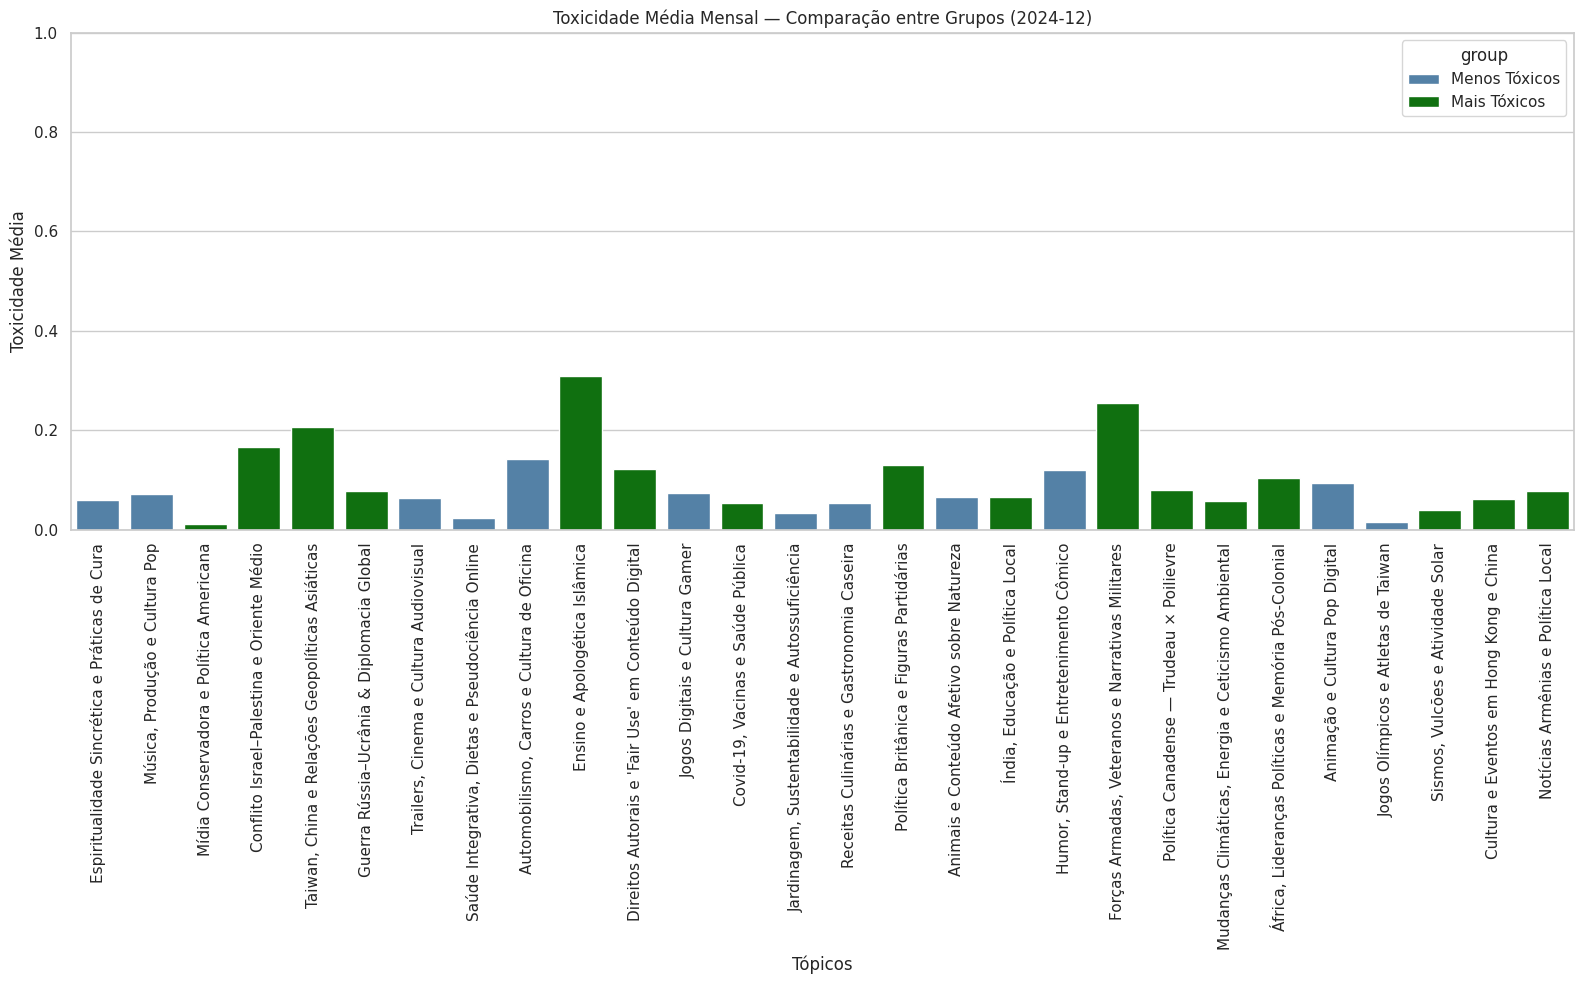

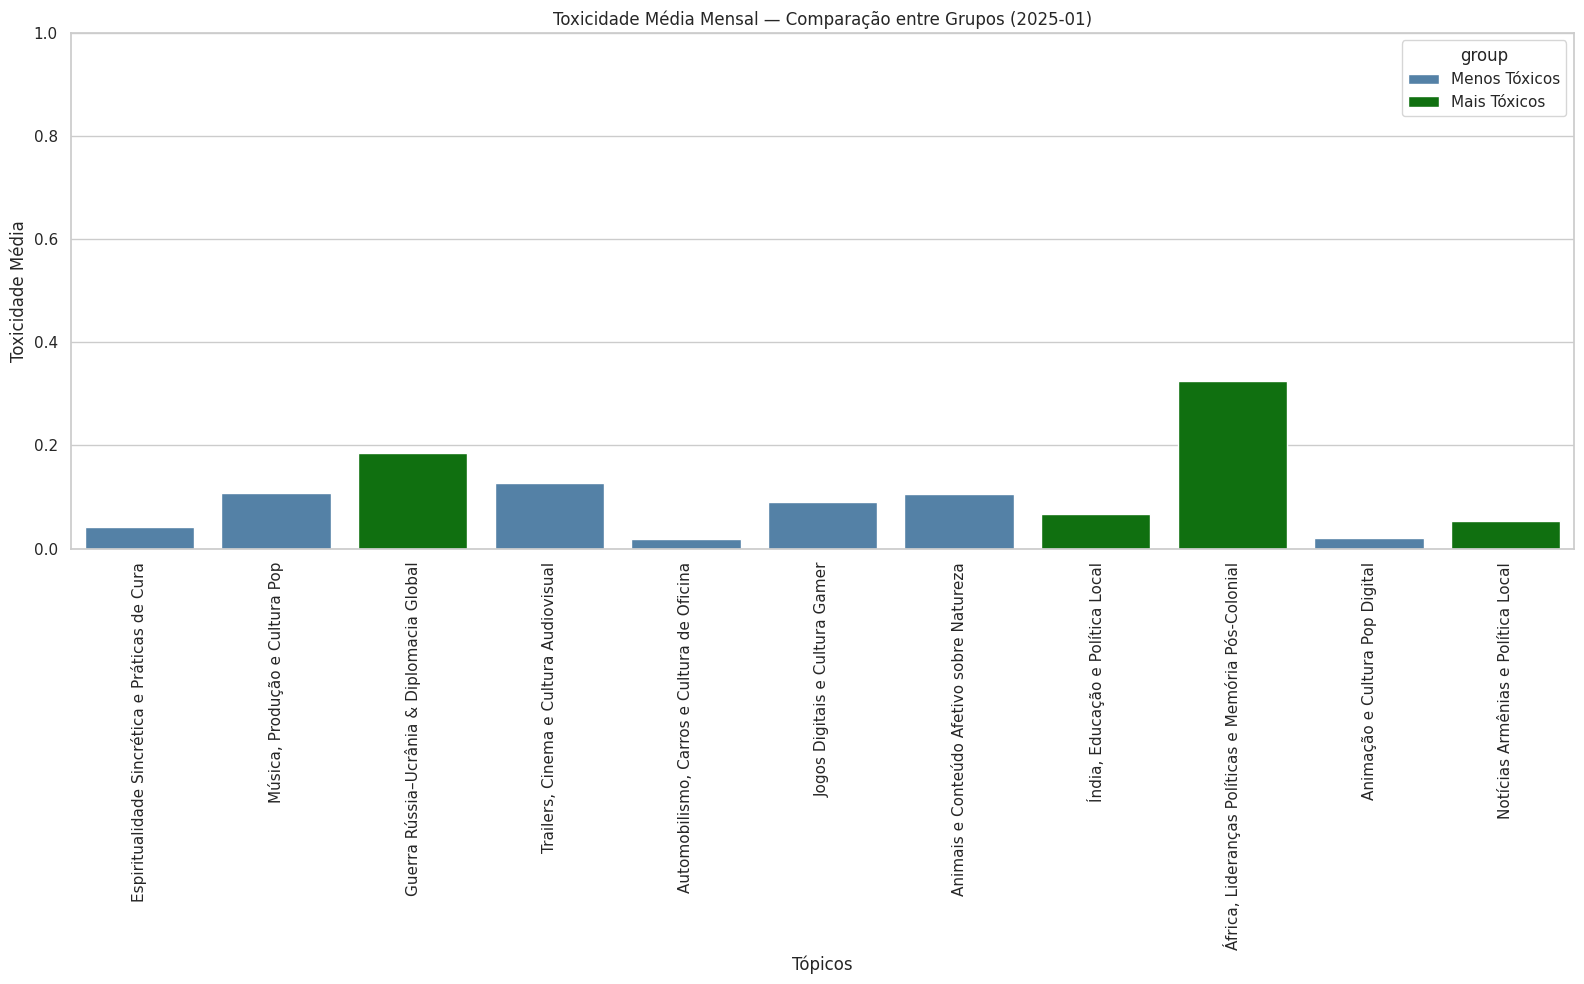

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que a data está no formato correto e cria coluna "month"
df_monthly_tox["date"] = pd.to_datetime(df_monthly_tox["date"])
df_monthly_tox["month"] = df_monthly_tox["date"].dt.to_period("M").dt.to_timestamp()

# Calcula toxicidade média mensal por tópico
df_monthly_topics = (
    df_monthly_tox
    .groupby(["month", "topic"])
    [["perspective_toxicity"]]
    .mean()
    .reset_index()
)

# Adiciona os nomes dos tópicos
df_monthly_topics["topic_name"] = df_monthly_topics["topic"].map(topic_names)

# Agora adiciona o grupo (mais/menos tóxico)
df_monthly_topics["group"] = df_monthly_topics["topic"].apply(
    lambda x: "Mais Tóxicos" if x in most_toxic_topics 
              else ("Menos Tóxicos" if x in less_toxic_topics else "Outro")
)

# Mantém apenas os grupos desejados
df_plot = df_monthly_topics[df_monthly_topics["group"] != "Outro"]

# --- Plotar ---
months = sorted(df_plot["month"].unique())

for month in months:
    month_df = df_plot[df_plot["month"] == month]

    plt.figure(figsize=(16, 10))
    
    sns.barplot(
        data=month_df,
        x="topic_name",
        y="perspective_toxicity",
        hue="group",
        palette={"Mais Tóxicos": "green", "Menos Tóxicos": "steelblue"}
    )

    plt.title(f"Toxicidade Média Mensal — Comparação entre Grupos ({month.strftime('%Y-%m')})")
    plt.xlabel("Tópicos")
    plt.ylabel("Toxicidade Média")
    plt.xticks(rotation=90)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1️⃣ Calcula a duração média por tópico ---

def calcular_duracao_video(occ_list):
    if not occ_list or pd.isna(occ_list):
        return None
    try:
        occ = eval(occ_list) if isinstance(occ_list, str) else occ_list
        datas = [pd.to_datetime(o["date"]) for o in occ if "date" in o]
        if len(datas) < 2:
            return 0
        return (max(datas) - min(datas)).days
    except Exception:
        return None

df_final["duracao_dias"] = df_final["occurrences"].apply(calcular_duracao_video)
df_valid = df_final.dropna(subset=["duracao_dias"])

df_duracao = (
    df_valid.groupby("topic")["duracao_dias"]
    .mean()
    .reset_index()
)

# --- 2️⃣ Adiciona nome e grupo (tóxico / não tóxico) ---
df_duracao["topic_name"] = df_duracao["topic"].map(topic_names)

df_duracao["group"] = "Neutro"
df_duracao.loc[df_duracao["topic"].isin(most_toxic_topics), "group"] = "Mais Tóxicos"
df_duracao.loc[df_duracao["topic"].isin(less_toxic_topics), "group"] = "Menos Tóxicos"

display(df_duracao)

,topic,duracao_dias,topic_name,group
0,-1,13.908913,Ruído / Sem Tópico,Neutro
1,0,17.106960,Espiritualidade Sincrética e Práticas de Cura,Menos Tóxicos
2,1,30.783282,"Música, Produção e Cultura Pop",Menos Tóxicos
3,2,6.893230,Mídia Conservadora e Política Americana,Mais Tóxicos
4,3,7.775842,"Criptomoedas, Airdrops e Finanças Digitais",Neutro
...,...,...,...,...
57,56,0.043103,Notícias Armênias e Política Local,Mais Tóxicos
58,57,13.975610,Redact News e Jornalismo Financeiro,Menos Tóxicos
59,58,3.279070,Mahyar Tousi e Merchandise Patriótico,Neutro
60,59,1.087719,Sean 'Diddy' Combs e Questões Legais,Mais Tóxicos


In [ ]:
df_duracao_plot = df_duracao[df_duracao["group"] != "Neutro"]

# --- 3️⃣ Plota ---
plt.figure(figsize=(14, 16))
sns.barplot(
    data=df_duracao_plot.sort_values("duracao_dias", ascending=False),
    x="duracao_dias",
    y="topic_name",
    hue="group",
    palette={"Mais Tóxicos": "green", "Menos Tóxicos": "blue"},
)
plt.title("⏱️ Duração Média dos Vídeos nas Mensagens por Tópico")
plt.xlabel("Duração Média (dias)")
plt.ylabel("Tópico")
plt.legend(title="Grupo")
plt.tight_layout()
plt.show()
